Import Libraries

In [83]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,cross_val_score, KFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

from sklearn import tree

Load Dataset

In [84]:
df = pd.read_csv("e_waste_cleaned_recoverable.csv")

df.head()

,Item,Category,Gold,Silver,Platinum,Rhodium,Nickel,Tin,Lithium,Aluminum,Carbon,Profit ($),Total_Value,Recoverable
0,iPhone 11,Cat3,3.58,2.95,1.73,8.92,1.91,1.01,1.82,1.27,9.51,270.34,1747.586811,1
1,Toaster,Cat2,7.21,4.31,6.21,5.63,9.59,7.65,0.51,3.03,4.22,689.75,1827.215202,1
2,Speaker,Cat4,8.91,5.09,2.42,7.70,1.09,1.49,7.42,3.63,8.83,570.43,1946.945103,1
3,Microwave Oven,Cat2,2.62,3.84,2.98,7.66,9.41,2.25,7.84,6.18,6.36,290.78,1595.124886,0
4,Air Conditioner,Cat1,3.47,3.89,6.20,4.35,5.07,8.65,8.62,0.82,5.53,505.16,1395.768663,0


Data Preprocessing

In [85]:
le = LabelEncoder()

df['Category'] = le.fit_transform(df['Category'])
df = df.drop(columns=["Item"])
df.head()

,Category,Gold,Silver,Platinum,Rhodium,Nickel,Tin,Lithium,Aluminum,Carbon,Profit ($),Total_Value,Recoverable
0,2,3.58,2.95,1.73,8.92,1.91,1.01,1.82,1.27,9.51,270.34,1747.586811,1
1,1,7.21,4.31,6.21,5.63,9.59,7.65,0.51,3.03,4.22,689.75,1827.215202,1
2,3,8.91,5.09,2.42,7.70,1.09,1.49,7.42,3.63,8.83,570.43,1946.945103,1
3,1,2.62,3.84,2.98,7.66,9.41,2.25,7.84,6.18,6.36,290.78,1595.124886,0
4,0,3.47,3.89,6.20,4.35,5.07,8.65,8.62,0.82,5.53,505.16,1395.768663,0


Define Features and Target

In [86]:
X = df.drop(["Recoverable", "Profit ($)", "Total_Value"], axis=1)
y = df["Recoverable"]

Train Test split

In [87]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

Decision Tree Model

In [88]:
model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

Predictions on Test data

In [89]:
y_pred = model.predict(X_test)

Cross Validation

In [91]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model, X, y, cv=kf, scoring="accuracy")

In [92]:
print("Cross Validation Scores:", scores)
print("Average Accuracy:", scores.mean())
print("Standard Deviation:", scores.std())

Cross Validation Scores: [0.9415 0.944  0.9395 0.953  0.932 ]
Average Accuracy: 0.942
Standard Deviation: 0.006804410334481569


Classification Report

In [93]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1307
           1       0.93      0.89      0.91       693

    accuracy                           0.94      2000
   macro avg       0.94      0.93      0.93      2000
weighted avg       0.94      0.94      0.94      2000



Confusion Matrix

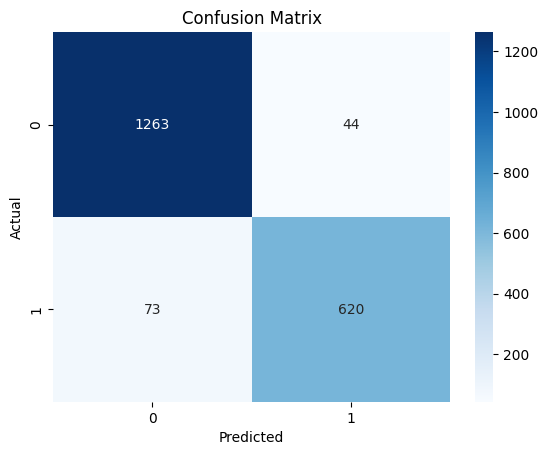

In [94]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()